In [1]:
year = 2023

In [2]:
from wind_wind.historical import get_generation, get_ARE_capacities

gen = get_generation(year)
cap = get_ARE_capacities(year)

historical_cf = gen/cap
historical_cf.name = f"Historical ({historical_cf.mean():.2%})"

In [3]:
historical_cf.mean()

np.float64(0.28222052874479997)

Cutout PL_2023.nc exists.
Cutout PL_2023.nc loaded.


INFO:atlite.data:Storing temporary files in C:\Users\Kajetan\AppData\Local\Temp\tmpml5zrt7f
INFO:atlite.convert:Convert and aggregate 'wind'.


20.251
Cutout PL_2023.nc exists.
Cutout PL_2023.nc loaded.


INFO:atlite.data:Storing temporary files in C:\Users\Kajetan\AppData\Local\Temp\tmpwgm9i01n
INFO:atlite.convert:Convert and aggregate 'wind'.


26.733


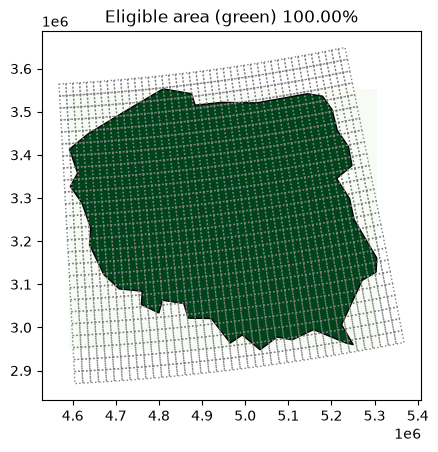

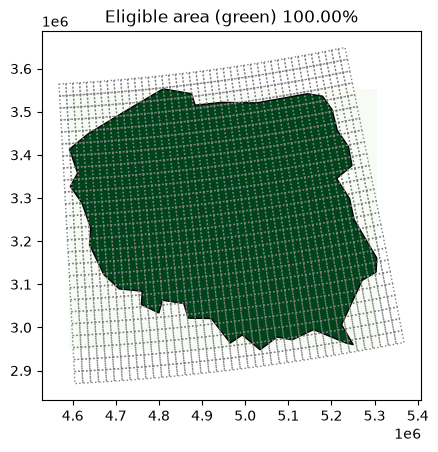

In [7]:
from wind_wind.profiles import Wind

cfs = []
profiles = []
for turbine_name in [
    "Vestas_V112_3MW",
    "2017COE_Market_Average_2.3MW_113",
    # "IEA_Reference_3.4MW_130"
]:
    wind_profile = Wind(turbine_name=turbine_name, smooth=True, weather_year=year)
    wind_profile.generate()
    profile = wind_profile.profile
    profile.name = f"{turbine_name} (smoothed) ({profile.mean():.2%})"
    cfs.append(wind_profile.cf)
    profiles.append(profile)
    print(wind_profile.cf)


In [8]:
import pandas as pd
df = pd.concat([historical_cf, *profiles], axis=1)
df

,Historical (28.22%),Vestas_V112_3MW (smoothed) (20.25%),2017COE_Market_Average_2.3MW_113 (smoothed) (26.73%)
snapshot,,,
2023-01-01 00:00:00,0.510692,0.760555,0.881613
2023-01-01 01:00:00,0.375416,0.774383,0.890502
2023-01-01 02:00:00,0.418898,0.781953,0.894661
2023-01-01 03:00:00,0.511513,0.787685,0.896569
2023-01-01 04:00:00,0.537454,0.775891,0.885313
...,...,...,...
2023-12-31 19:00:00,0.406396,0.252419,0.348630
2023-12-31 20:00:00,0.375298,0.241268,0.333487
2023-12-31 21:00:00,0.363836,0.223878,0.310156


<Axes: xlabel='snapshot'>

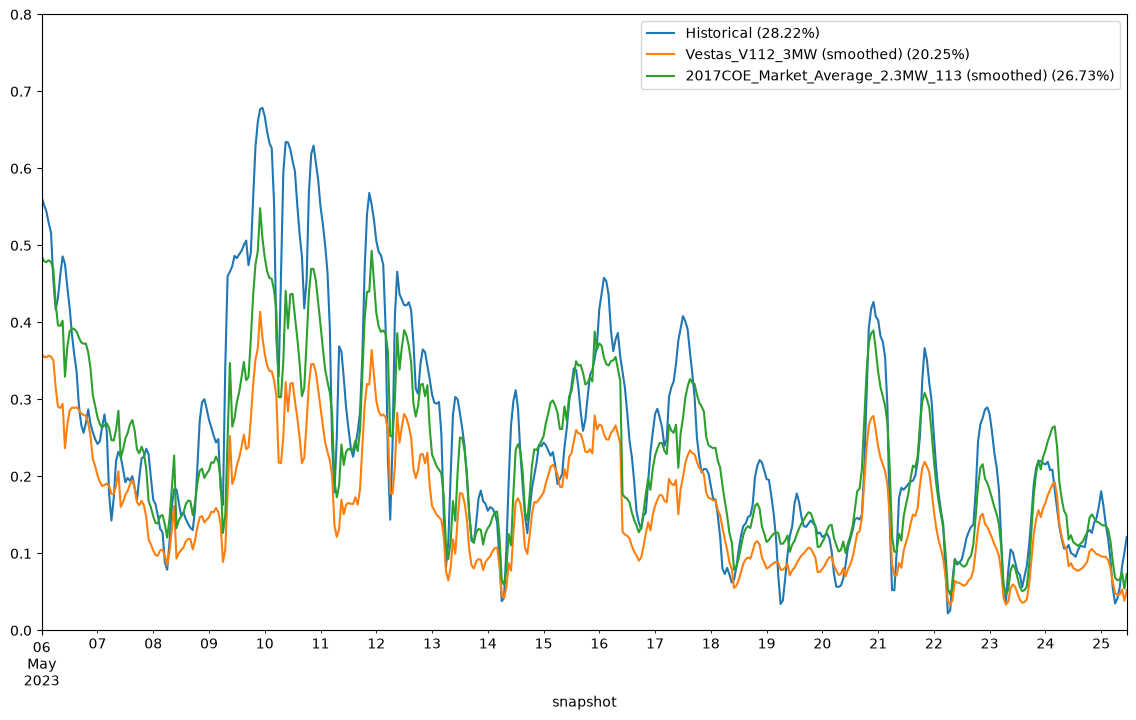

In [9]:
df[3000:3468].plot(figsize=(14,8), ylim=(0, 0.8))